In [1]:
%load_ext autoreload
%autoreload 2

# Process PROTACpedia structure file

In [1]:
import os
os.makedirs('data/PDB',exist_ok=True)
from pymol import cmd
from time import sleep
import pandas as pd
from detect_pocket import get_pocket_info_from_pdb_info

In [ ]:
pdb_df=pd.read_excel('data/PROTACpedia_pdb.xlsx',sheet_name='pdb_ref',dtype=str)
for idx,(pdbid,ligid,chain_poi,chain_lig,*_) in pdb_df.iterrows():
    try:
        pdbid=pdbid.lower()
        sleep(3)
        cmd.reinitialize()
        cmd.fetch(pdbid,name=f'{pdbid}',type='cif',path='data/PDB')
    except Exception as e:
        print(e)
        continue
pdb_df[['seq_can','boltz_pocket']]=pdb_df.apply(lambda row:get_pocket_info_from_pdb_info(row['pdbid'],row['ligid'],row['chain_poi'],row['chain_lig'],radius=4),axis=1,result_type='expand')

In [3]:
pedia_df=pd.read_excel('data/PROTACpedia_pdb.xlsx',sheet_name='full_info',)
pdb_refs=pdb_df['UniprotID'].values

def have_pdb_ref(target:str) -> int:
    try:
        targets=target.split(', ')
        for target in targets:
            if target in pdb_refs:
                return 1
        return 0
    except:return 0

pedia_df['have_pdb_ref']=pedia_df['Target'].apply(have_pdb_ref)

In [4]:
def pdb_ref(target:str) -> str:
    try:
        targets=target.split(', ')
        for target in targets:
            if target in pdb_refs:
                return target
        return pd.NA
    except:return pd.NA
pedia_df['pdb_ref']=pedia_df['Target'].apply(pdb_ref)

In [5]:
from util import smi2inchikey
pedia_df['inchikey']=pedia_df['PROTAC SMILES'].apply(smi2inchikey)

In [6]:
pedia_merge=pedia_df.merge(pdb_df,left_on='pdb_ref',right_on='UniprotID')

In [7]:
pedia_merge['E3 Ligase']=pedia_merge['E3 Ligase'].str.lower().str.replace('cereblon','crbn')
pedia_merge['pdbid']=pedia_merge['pdbid'].str.lower()
pedia_merge[pedia_merge['E3 Ligase'].isin(('vhl','crbn'))].dropna(subset=['pdb_ref','inchikey']).to_csv('data/pedia_extend.csv',index=False)

In [8]:
cmd.reinitialize()
cmd.fetch('8rqa',name='8rqa',type='cif',path='data/PDB')
get_pocket_info_from_pdb_info('8rqa','LVY','A','A',radius=4)

('SAKKPNIINFDTSLPTSHTYLGADMEEFHGRTLHDDDSIQVIPVLPQVMMILVPGQTLPLQLFHPQEVSMVRNLIQNDRTFAVLAYSNVQEREAEFGTTAEIYAYREEQDFGIEIVKVKAIGRQRFKVLELRTQSDGIQQAKVQILPEGSGDAETLMDRIKKQLREWDENLKDDSLPSNPIDFSYWVAANLPIDDSLRIQLLKIDSAIQRLRCELDIMNKCTSLCCKQCQETEITTKNEIFSLSREGPMAAYVNPHGYVHEILTVYKACNLNLIGRPSTEHSWFPGYAWTVAQCKICASHIGWKFTATKKDMSPQKFWGLTRSALIPTI',
 [283, 289, 282, 255, 254, 281, 305, 303, 256])

In [9]:
cmd.reinitialize()
cmd.fetch('6gfy',name='6gfy',type='cif',path='data/PDB')
get_pocket_info_from_pdb_info('6gfy','EXH','C','C',radius=4)

('GSMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQPYPTLPPGTGRRIHSYRGHLWLFRDAGTHDGLLVNQTELFVPSLNVDGQPIFANITLPVYTLKERCLQVVRSLVKPENYRRLDIVRSLYEDLEDHPNVQKDLERLTQERIAHQRMGD',
 [60, 61, 66, 37, 64, 58, 40, 59, 48, 47])

# Get boltz MSA files

In [ ]:
import shutil
from util import get_a3m
os.makedirs('data/MSA',exist_ok=True)
for _,(pdbid,seq) in pdb_df[['pdbid','seq_can',]].iterrows():
    pdbid=pdbid.lower()
    get_a3m(seq,pdbid)

In [16]:
!rm -r data/MSA/*_env
!rm data/MSA/*_tmp.a3m

zsh:1: no matches found: data/MSA/*_tmp.a3m


In [ ]:
get_a3m('SAKKPNIINFDTSLPTSHTYLGADMEEFHGRTLHDDDSIQVIPVLPQVMMILVPGQTLPLQLFHPQEVSMVRNLIQNDRTFAVLAYSNVQEREAEFGTTAEIYAYREEQDFGIEIVKVKAIGRQRFKVLELRTQSDGIQQAKVQILPEGSGDAETLMDRIKKQLREWDENLKDDSLPSNPIDFSYWVAANLPIDDSLRIQLLKIDSAIQRLRCELDIMNKCTSLCCKQCQETEITTKNEIFSLSREGPMAAYVNPHGYVHEILTVYKACNLNLIGRPSTEHSWFPGYAWTVAQCKICASHIGWKFTATKKDMSPQKFWGLTRSALIPTI','data/MSA/8rqa')
get_a3m('GSMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQPYPTLPPGTGRRIHSYRGHLWLFRDAGTHDGLLVNQTELFVPSLNVDGQPIFANITLPVYTLKERCLQVVRSLVKPENYRRLDIVRSLYEDLEDHPNVQKDLERLTQERIAHQRMGD','data/MSA/6gfy')

In [ ]:
import shutil
shutil.move('data/MSA/8rqa.a3m','data/MSA/crbn.a3m')
shutil.move('data/MSA/6gfy.a3m','data/MSA/vhl.a3m')

'data/MSA/vhl.a3m'

# Precompute

In [9]:
import pandas as pd
from reinvent_plugins.components.boltz_interface import calculate_affinity_score,run_superpose_scoring_items_calc
from ast import literal_eval
pedia_extend=pd.read_csv('data/pedia_extend.csv',header='infer')

import os
os.environ['BOLTZ_CACHE']= '~/projects/boltz'

In [ ]:
tmp_result=[]
for lig_smi,inchikey,name_poi,seq_poi,pocket_poi,name_e3 in pedia_extend[['PROTAC SMILES','inchikey','pdbid','seq_can','boltz_pocket','E3 Ligase']].itertuples(False):
    tmp_result.extend(calculate_affinity_score(lig_smi,inchikey,name_poi,seq_poi,literal_eval(pocket_poi),name_e3,extract_from_precomputed=False))

In [20]:
sc_df=pd.DataFrame(tmp_result,columns=['pdbid','E3 Ligase','inchikey','lgKd_poi','lgKd_e3','lgKd_ternary','ref_model','dist_ub','has_surf_lys','bsa','num_clash'])
sc_df=sc_df.astype({'lgKd_poi':float,'lgKd_e3':float,'lgKd_ternary':float,'ref_model':str,'dist_ub':float,'has_surf_lys':int,'bsa':float,'num_clash':float})
sc_df=sc_df[sc_df['lgKd_ternary']!=float('inf')]

In [48]:
pedia_precompute=pd.merge(pedia_extend,sc_df,on=['pdbid', 'E3 Ligase', 'inchikey'], how='inner').drop_duplicates(['pdbid', 'E3 Ligase', 'inchikey','ref_model'],keep='first') # activity in different cells are different records

In [49]:
pedia_precompute['Active/Inactive']=(pedia_precompute['Active/Inactive']=='Active').astype(int)
pedia_precompute['lg_alpha']=pedia_precompute['lgKd_poi']+pedia_precompute['lgKd_e3']-pedia_precompute['lgKd_ternary']
pedia_precompute.astype({'PROTACDB ID':int}).to_csv('data/pedia_precompute.csv',index=False)

# Train scoring weights

In [3]:
import pandas as pd
pedia_precompute=pd.read_csv('data/pedia_precompute.csv',header='infer')
pedia_precompute=pedia_precompute[(abs(pedia_precompute['lg_alpha'])!=float('inf'))&(~pedia_precompute['lg_alpha'].isna())]
pedia_precompute['dist_ub_square']=pedia_precompute['dist_ub']**2
len(pedia_precompute)

4851

In [ ]:
test_df=pedia_precompute.copy()
test_df=test_df.sort_values(by='dist_ub_square')
test_df=test_df.drop_duplicates(['pdbid', 'E3 Ligase', 'inchikey'],keep='first')

In [76]:
test_df[test_df['E3 Ligase']=='crbn']['ref_model'].value_counts()

ref_model
model9_clean.pdb     120
model12_clean.pdb    110
model1_clean.pdb      95
model2_clean.pdb      62
model4_clean.pdb      47
model5_clean.pdb      33
model3_clean.pdb      31
model10_clean.pdb      3
model11_clean.pdb      1
Name: count, dtype: int64

<Axes: >

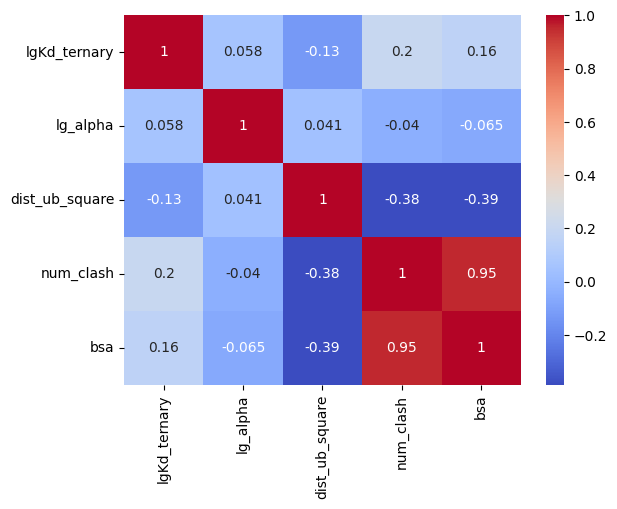

In [3]:
import seaborn as sns
sns.heatmap(test_df[['lgKd_ternary','lg_alpha','dist_ub_square','num_clash','bsa']].corr(), annot=True, cmap='coolwarm')

In [62]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_val_score
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')
def train_linercv_weight(df,feature_cols:list[str], scaler=None):
    target_col = 'Active/Inactive'
    X = df[feature_cols]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
    if scaler is None:
        X_train_scaled = X_train
        X_test_scaled = X_test
    else:
        s = scaler()
        X_train_scaled = s.fit_transform(X_train)
        X_test_scaled = s.transform(X_test)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    cv_ridge = cross_val_score(RidgeClassifier(class_weight='balanced'), X_train_scaled, y_train, 
                         scoring='roc_auc', cv=skf)
    print(f'Ridge train set ROC-AUC: {float(np.mean(cv_ridge)):.4f} ± {float(np.std(cv_ridge)):.4f}')
    ridge_final = RidgeClassifier(class_weight='balanced')
    ridge_final.fit(X_train_scaled, y_train)
    y_test_scores = ridge_final.decision_function(X_test_scaled)
    print(f'Ridge test set ROC-AUC: {roc_auc_score(y_test, y_test_scores):.4f}')
    print('Ridge coefficients:')
    coef = ridge_final.coef_
    if coef.ndim > 1:
        coef = coef[0]
    for feat, coef_val in zip(feature_cols, coef):
        print(f'  {feat}: {coef_val:.4f}')
    intercept = ridge_final.intercept_
    if hasattr(intercept, '__iter__') and not isinstance(intercept, (str, bytes)):
        intercept = intercept[0]
    print(f'  intercept: {intercept:.4f}\n')
    
    return ridge_final,X_test_scaled,y_test,s

models = train_linercv_weight(test_df,['lgKd_ternary','dist_ub_square','num_clash'], QuantileTransformer)

Ridge train set ROC-AUC: 0.5866 ± 0.0673
Ridge test set ROC-AUC: 0.5478
Ridge coefficients:
  lgKd_ternary: -0.4427
  dist_ub_square: -0.0585
  num_clash: -0.2191
  intercept: 0.3496



In [34]:
test_df['group_mean'] = test_df.groupby('pdbid')['Active/Inactive'].transform('mean')

In [52]:
test_df[(test_df['group_mean'] > 0.25) & (test_df['group_mean'] < 0.75)].value_counts('pdbid').head()

pdbid
2gqg    69
3ika    49
5eu1    46
1r5k    40
1hwk    39
Name: count, dtype: int64

In [66]:
model_2gqg = train_linercv_weight(test_df[test_df['pdbid']=='2gqg'],['lgKd_ternary','dist_ub_square','bsa'], QuantileTransformer)
model_3ika = train_linercv_weight(test_df[test_df['pdbid']=='3ika'],['lgKd_ternary','dist_ub_square','num_clash'], QuantileTransformer)
model_crbn=train_linercv_weight(test_df[test_df['E3 Ligase']=='crbn'],['lgKd_ternary','dist_ub_square','num_clash'], QuantileTransformer)
model_crbn=train_linercv_weight(test_df[test_df['E3 Ligase']=='vhl'],['lgKd_ternary','dist_ub_square','num_clash'], QuantileTransformer)

Ridge train set ROC-AUC: 0.7800 ± 0.1360
Ridge test set ROC-AUC: 0.7708
Ridge coefficients:
  lgKd_ternary: -0.6912
  dist_ub_square: -0.1498
  bsa: 1.1096
  intercept: -0.0013

Ridge train set ROC-AUC: 0.8200 ± 0.2509
Ridge test set ROC-AUC: 0.8095
Ridge coefficients:
  lgKd_ternary: -1.7983
  dist_ub_square: -0.4033
  num_clash: -0.0411
  intercept: 1.2341

Ridge train set ROC-AUC: 0.6544 ± 0.0478
Ridge test set ROC-AUC: 0.6488
Ridge coefficients:
  lgKd_ternary: -0.8853
  dist_ub_square: -0.0526
  num_clash: -0.1278
  intercept: 0.5586

Ridge train set ROC-AUC: 0.4473 ± 0.0600
Ridge test set ROC-AUC: 0.6107
Ridge coefficients:
  lgKd_ternary: 0.1782
  dist_ub_square: -0.1204
  num_clash: -0.2640
  intercept: -0.0216



In [68]:
import joblib
joblib.dump(models[3],'data/scaler.pkl')

['data/scaler.pkl']

In [72]:
sc_active=3/((1/(1-models[3].transform(test_df[test_df['Active/Inactive']==1][['lgKd_ternary','dist_ub_square','num_clash']]))).sum(axis=1))
np.percentile(sc_active, 50),np.mean(sc_active),np.std(sc_active),

(0.36181434802086443, 0.36441005269992144, 0.19210786067036756)

In [73]:
sc_inact=3/((1/(1-models[3].transform(test_df[test_df['Active/Inactive']==0][['lgKd_ternary','dist_ub_square','num_clash']]))).sum(axis=1))
np.percentile(sc_inact, 50),np.mean(sc_inact),np.std(sc_inact),

(0.3030318213475095, 0.3087416780969295, 0.19473533591102166)

# FGFR4 Agent Training

In [7]:
from detect_pocket import get_pocket_info_from_pdb_info
from pymol import cmd
cmd.reinitialize()
cmd.fetch('4xcu',name='4xcu',type='cif',path='data/PDB')
get_pocket_info_from_pdb_info('4xcu','40M','A','A',radius=4)

('MVSLDLPLDPLWEFPRDRLVLGKPLGEGCFGQVVRAEAFGMDPARPDQASTVAVKMLKDNASDKDLADLVSEMEVMKLIGRHKNIINLLGVCTQEGPLYVIVECAAKGNLREFLRARRPPGSSEGPLSFPVLVSCAYQVARGMQYLESRKCIHRDLAARNVLVTEDNVMKIADFGLARGVHHIDYYKKTSNGRLPVKWMAPEALFDRVYTHQSDVWSFGILLWEIFTLGGSPYPGIPVEELFSLLREGHRMDRPPHCPPELYGLMRECWHAAPSQRPTFKQLVEALDKVLLAVSHHHHHH',
 [162,
  174,
  173,
  108,
  102,
  104,
  105,
  35,
  86,
  172,
  103,
  55,
  100,
  72,
  25,
  33,
  76])

In [ ]:
from reinvent_plugins.components.comp_boltz_fgfr4 import calculate_one_affinity_score
calculate_one_affinity_score('CCC(=O)Nc1cc(cc(c1Nc1ncc2c(n1)ccc(c2)c1c(Cl)c(OC)cc(c1Cl)OC)C)N1CCN(CC1)CC1CCN(CC1)c1cccc2c1C(=O)N(C2=O)C1CCC(=O)NC1=O','fgfr4','MVSLDLPLDPLWEFPRDRLVLGKPLGEGCFGQVVRAEAFGMDPARPDQASTVAVKMLKDNASDKDLADLVSEMEVMKLIGRHKNIINLLGVCTQEGPLYVIVECAAKGNLREFLRARRPPGSSEGPLSFPVLVSCAYQVARGMQYLESRKCIHRDLAARNVLVTEDNVMKIADFGLARGVHHIDYYKKTSNGRLPVKWMAPEALFDRVYTHQSDVWSFGILLWEIFTLGGSPYPGIPVEELFSLLREGHRMDRPPHCPPELYGLMRECWHAAPSQRPTFKQLVEALDKVLLAVSHHHHHH',[104,35,105,86,181,100,25,76,103,33,182,183,102,72,55,171,108],'crbn',output_path='data/fgfr4',msa_path='data/fgfr4',extract_from_precomputed=True)

INFO:root:Predicting data/fgfr4/fgfr4_crbn_AMZUZKXFLXHAHI-UHFFFAOYSA-N_ternary.yaml
INFO:root:Calculating superposing sc items: fgfr4_crbn_AMZUZKXFLXHAHI-UHFFFAOYSA-N_ternary
INFO:root:lgKd_ternary: -3.853,dist_ub_square: 2475.320, boltz weighted score: -0.080


-0.08049112457695096

In [2]:
from reinvent_plugins.components.comp_boltz_fgfr4 import generate_boltz_covalent_or_not_ternary_yaml
generate_boltz_covalent_or_not_ternary_yaml('CCC(=O)Nc1cc(N2CCN(CC3CCN(c4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)CC3)CC2)cc(C)c1Nc1ncc2cc(-c3c(Cl)c(OC)cc(OC)c3Cl)ccc2n1', 'seq_poi', [1,2,3], 'msa_poi', 'seq_e3',
                                [4,5,6], 'msa_e3', 'yaml_ternary.yaml',True)

## Sampling and clustering FGFR4 candidates 

Use sample mode of REINVENT to find a couple of promising linkers. Cluster them to find a series of compounds.

In [ ]:
!reinvent -s 0 -l boltz_fgfr4_crbn_sample.log boltz_fgfr4_crbn_sample.toml

In [95]:
import pandas as pd
from rdkit.Chem import rdRascalMCES,MolFromSmiles
fgfr_crbn_samples=pd.read_csv('boltz_fgfr_crbn_sampling.csv',header='infer')
fgfr_crbn_samples['Linker']=fgfr_crbn_samples['Linker'].str.replace('[*]','[Po]',1).str.replace('[*]','[Es]',1) # mark the start and end connect points
fgfr_crbn_samples['mol']=fgfr_crbn_samples['Linker'].apply(MolFromSmiles)
cluster_mols=rdRascalMCES.RascalCluster(fgfr_crbn_samples['mol'])

In [96]:
fgfr_crbn_samples['cluster'] = -1
for cluster_id, cluster_indices in enumerate(cluster_mols):
    for idx in cluster_indices:
        fgfr_crbn_samples.loc[idx, 'cluster'] = cluster_id
fgfr_crbn_samples.to_csv('boltz_fgfr_crbn_sampling_clustered.csv',index=False,columns=[c for c in fgfr_crbn_samples.columns if c!='mol'])
fgfr_crbn_samples.groupby('cluster')['NLL'].mean()

cluster
0     11.843115
1      8.815250
2     13.102000
3      7.292500
4     13.726667
5      6.457500
6      8.650000
7     13.865000
8     13.540000
9     11.105000
10    13.675000
11    18.661111
Name: NLL, dtype: float64

In [100]:
fgfr_crbn_samples[fgfr_crbn_samples['cluster']==6]

,SMILES,SMILES_state,Warheads,Linker,NLL,mol,cluster
136,CCC(=O)Nc1cc(C2(C)CCC(OC3CCC(Nc4cccc5c4C(=O)N(...,1,*c1cc(C)c(Nc2ncc3cc(-c4c(Cl)c(OC)cc(OC)c4Cl)cc...,[Po]C1(C)CCC(OC2CCC(N[Es])CC2)CC1,8.65,<rdkit.Chem.rdchem.Mol object at 0x7fa230b34b30>,6


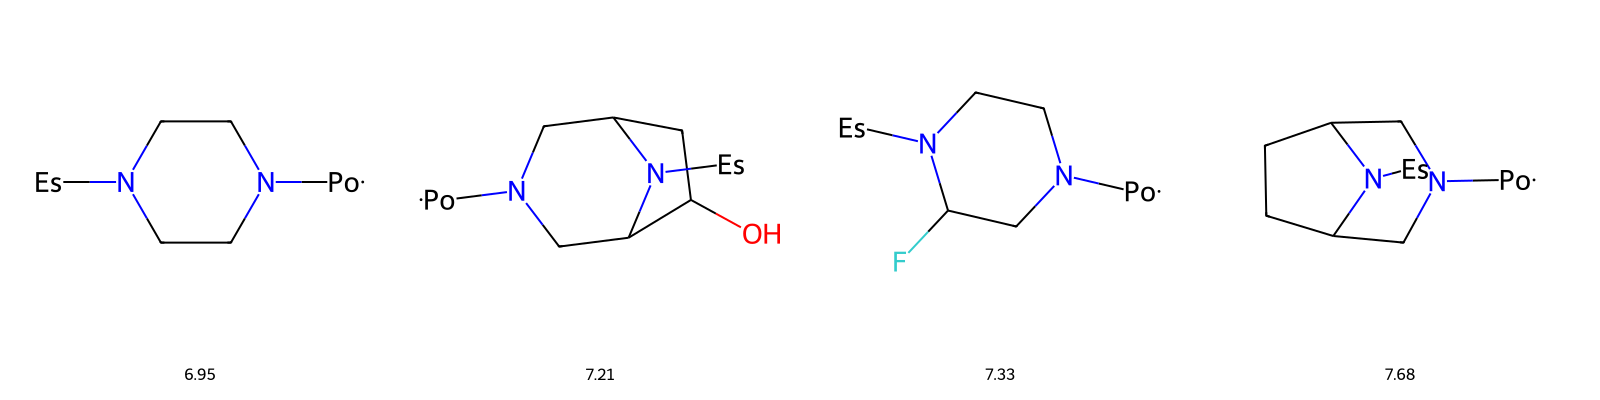

In [101]:
from rdkit.Chem import Draw
cluster3=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==3].sort_values('NLL')
cluster5=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==5].sort_values('NLL')
cluster6=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==6].sort_values('NLL')
cluster1=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==1].sort_values('NLL')
def draw_cluster_mols(df):
    mols = df['mol'].tolist()
    legends = df['NLL'].astype('str').tolist() 
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(400, 400), legends=legends)
    display(img)
draw_cluster_mols(cluster3)

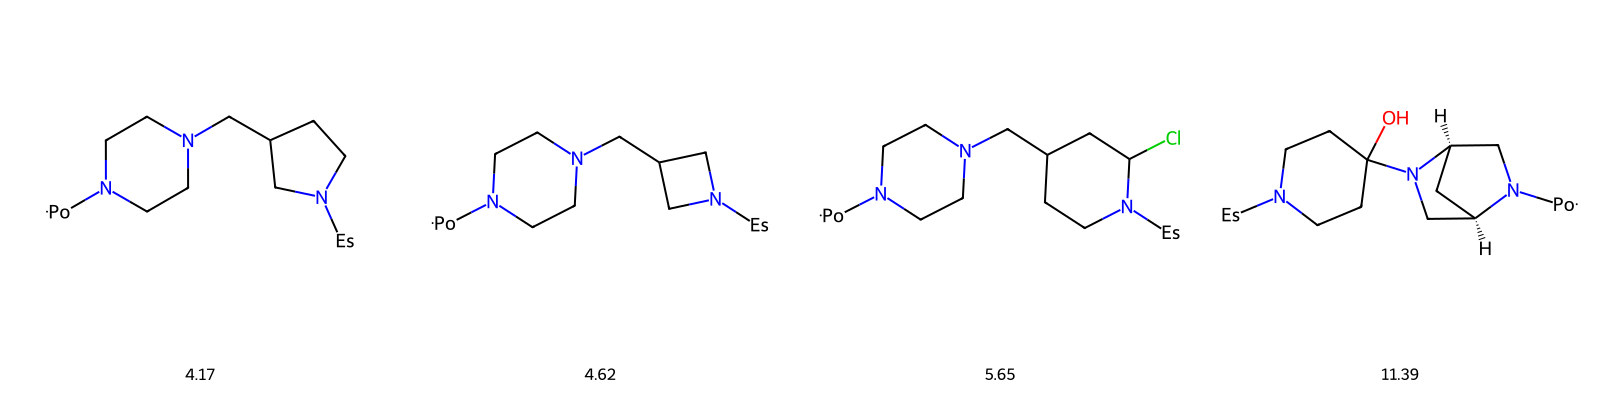

In [102]:
draw_cluster_mols(cluster5)

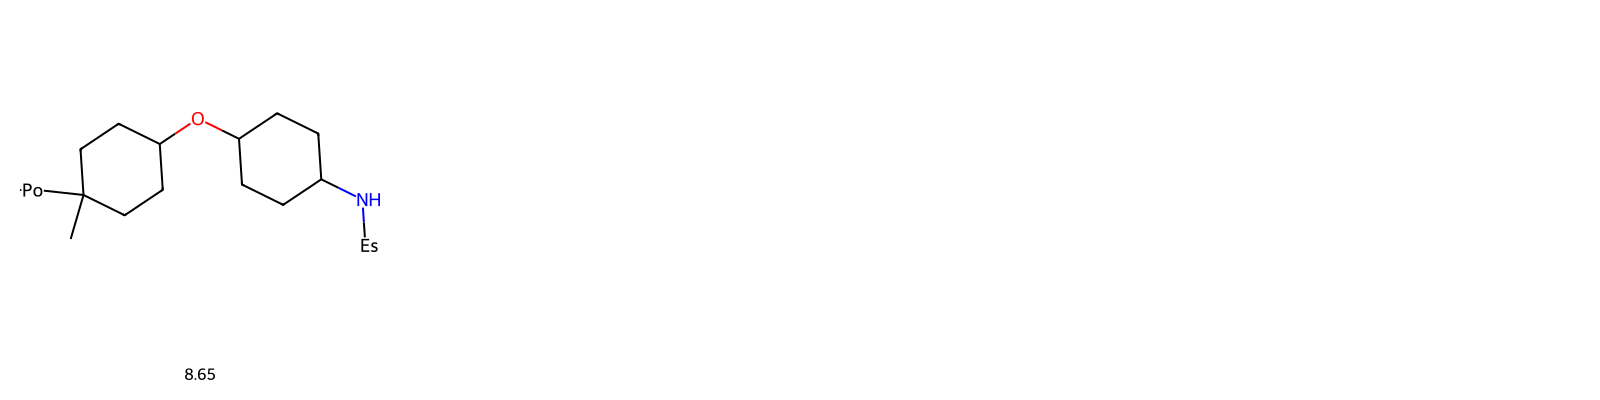

In [104]:
draw_cluster_mols(cluster6)

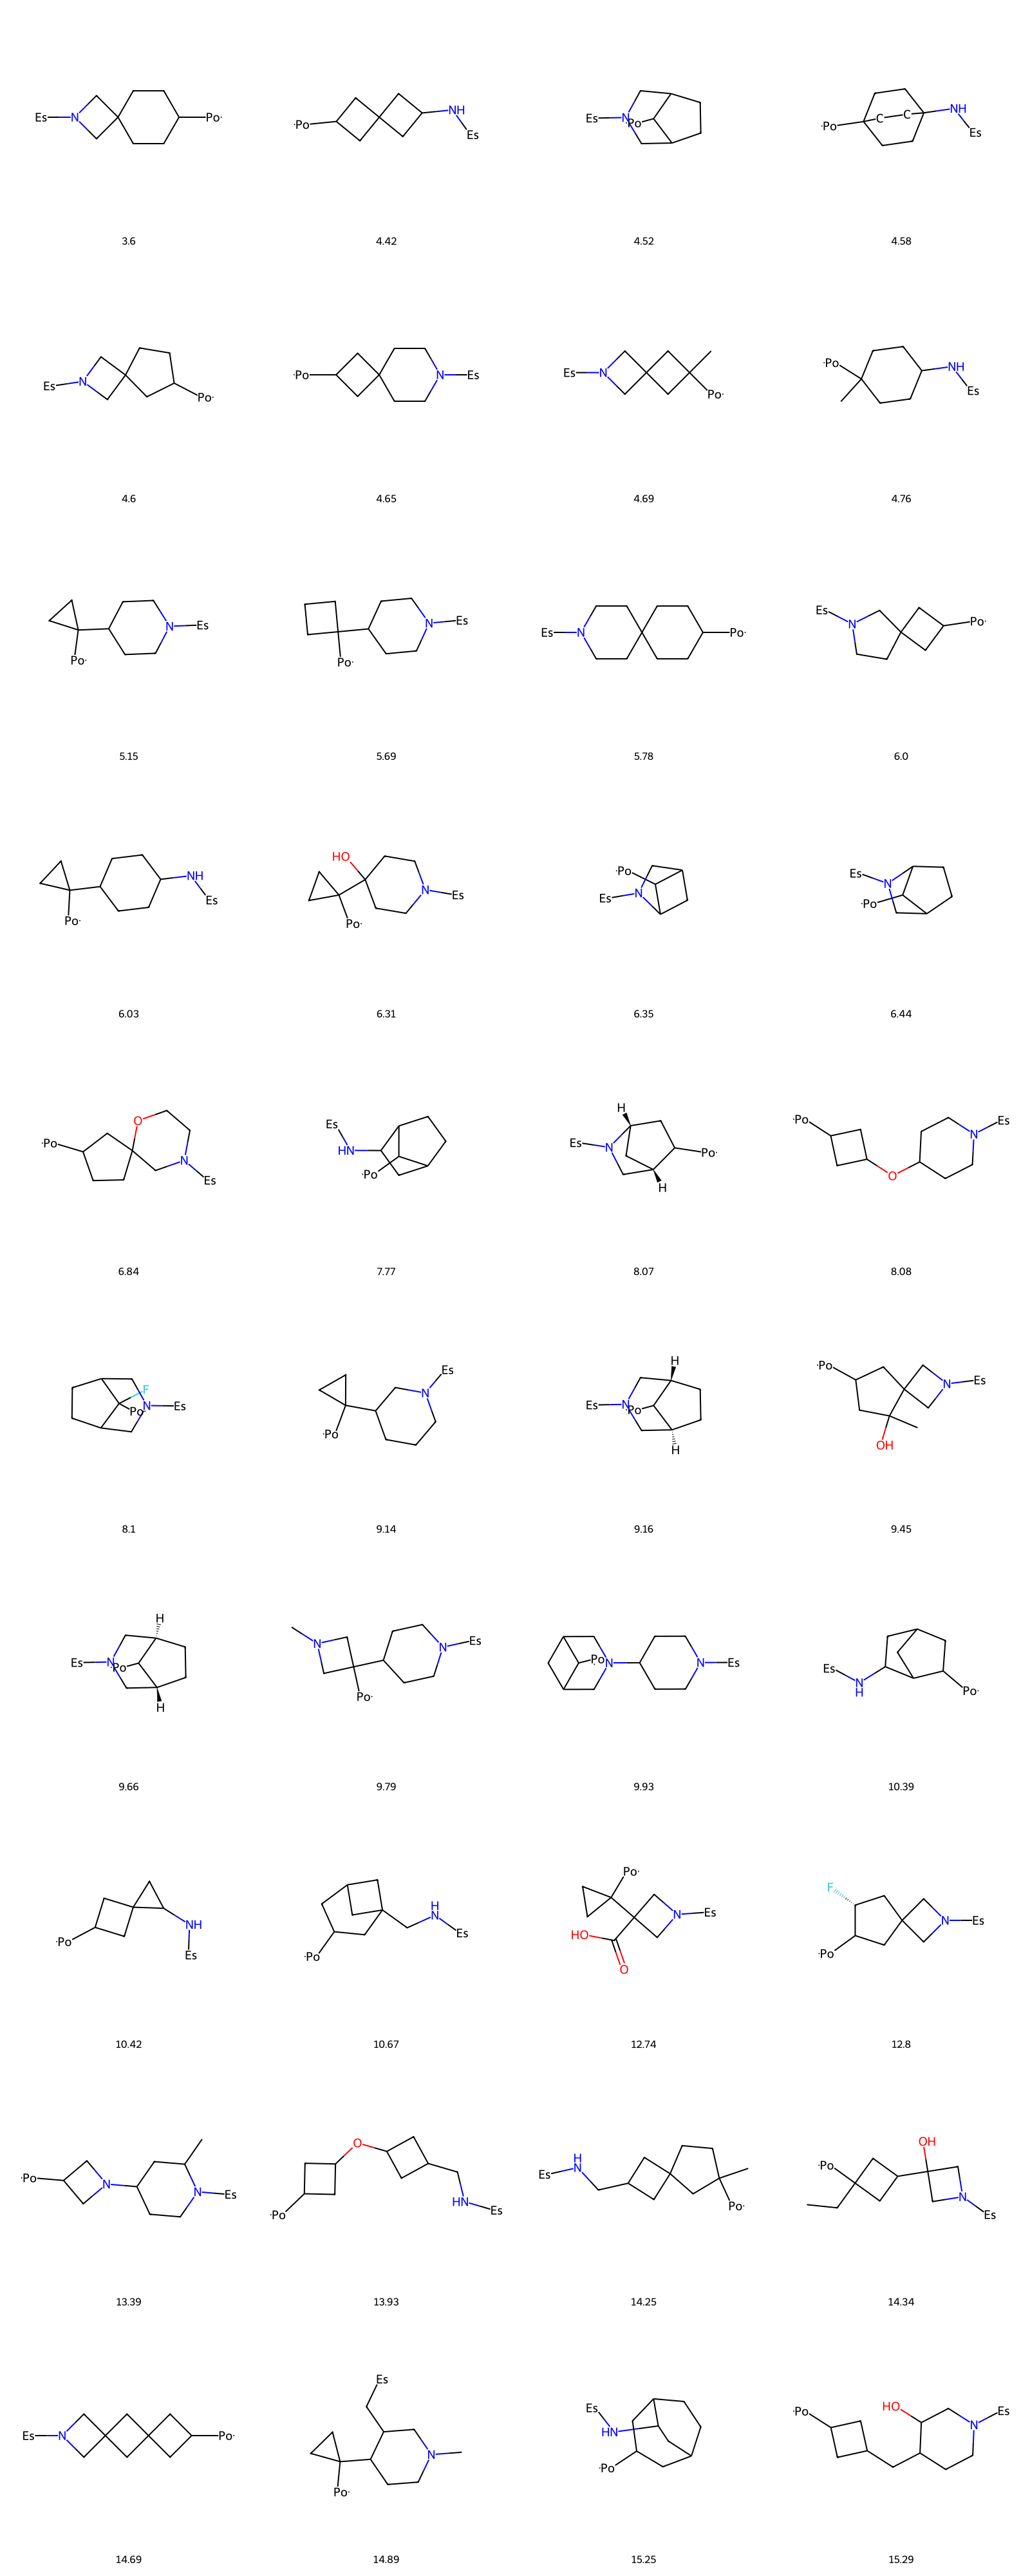

In [105]:
draw_cluster_mols(cluster1)